### Question 3

Image shape: (768, 1024, 3)
Flag shape: (150, 225, 3)
Selected Points: [(148, 207), (522, 290), (519, 464), (135, 447)]
Homographic Matrix: 
[[ 2.55882186e+00 -1.08142247e-01  1.48000000e+02]
 [ 8.64524047e-01  1.54155615e+00  2.07000000e+02]
 [ 1.70340804e-03 -1.54769816e-04  1.00000000e+00]]


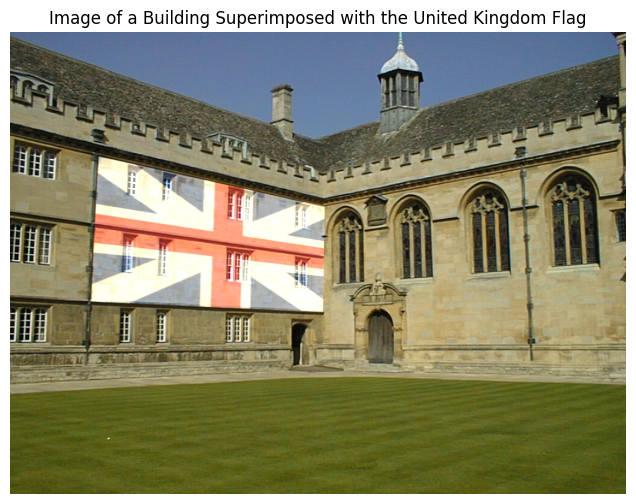

In [15]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# ---- mouse callback ----
clicked_points = []
def point_selection(action, x, y, flags, param):
    global clicked_points, base_disp
    if action == cv.EVENT_LBUTTONDOWN and len(clicked_points) < 4:
        clicked_points.append((x, y))
        cv.circle(base_disp, (x, y), 5, (0, 0, 255), -1)
        cv.imshow('Base Image', base_disp)

# ---- load images (keep alpha if PNG) ----
base_img  = cv.imread('Building.jpg', cv.IMREAD_COLOR)
adding_img = cv.imread('flag.png', cv.IMREAD_UNCHANGED)
if base_img is None or adding_img is None:
    raise FileNotFoundError("Check paths: 'Building.jpg' / 'flag.png'")

# ---- show & pick 4 points on base image (order: TL, TR, BR, BL) ----
base_disp = base_img.copy()
cv.namedWindow('Base Image', cv.WINDOW_AUTOSIZE)
cv.imshow('Base Image', base_disp)
cv.setMouseCallback('Base Image', point_selection)
while len(clicked_points) < 4:
    if cv.waitKey(10) == 27:  # ESC to abort
        break
cv.destroyAllWindows()

# ---- prepare source/destination quads ----
dst = np.array(clicked_points, dtype=np.float32)                       # TL,TR,BR,BL
h2, w2 = adding_img.shape[:2]
src = np.array([[0,0],[w2-1,0],[w2-1,h2-1],[0,h2-1]], dtype=np.float32)

print("Image shape:", base_img.shape)
print("Flag shape:", adding_img.shape)
print("Selected Points:", clicked_points)

# ---- homography ----
H = cv.getPerspectiveTransform(src, dst)
print('Homographic Matrix: ')
print(H)

# Warping the adding image with the homography
warped_img = cv.warpPerspective(adding_img, H, (base_img.shape[1], base_img.shape[0]))

# Superimposing the warped image with the base image
supimp_img = cv.addWeighted(base_img, 1, warped_img, 0.5, 0)

plt.figure(figsize=(12,6))
plt.imshow(cv.cvtColor(supimp_img, cv.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Image of a Building Superimposed with the United Kingdom Flag')
plt.show()

